### Decomposition


#### 一、 核心逻辑：分而治之
查询拆解的本质是将一个复杂的输入问题分解为一组可以独立解决的子问题
- 对于符合复合型问题，直接进行语义检索往往只能找回碎片化的信息，导致大模型难以给出完整且有深度的回答
- 比如处理“单词末尾字母拼接”这类复杂任务时，先拆解成处理单个单词的子任务，再将结果汇总

#### 二、两种拆解策略
- 串行/交替检索 (Sequential/Interleaved Retrieval)：将检索与思维链（Chain of Thought）推理结合在一起
  - 首先回答第一个子问题；然后将该问题的“问答对”作为背景背景，去辅助解决第二个子问题；以此类推，像剥洋葱一样层层递进
  - 后一个问题的检索和生成可以基于前一个问题的结果，非常适合逻辑关联性强、需要多步推理的问题  

- 并行检索 (Parallel Retrieval)
  - 将主问题拆解后，同时对所有子问题进行独立检索和回答，最后将所有的“问答对”拼接在一起，生成最终答案
  - 适用于那些子问题之间相互独立、互不依赖的情况

In [1]:
# Indexing
import bs4
from langchain_community.document_loaders import WebBaseLoader
loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)
blog_docs = loader.load()
print(blog_docs)


c:\Users\23017\anaconda3\envs\rag_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='\n\n      LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\n\n\nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistake

In [2]:
#Split
from langchain_text_splitters import CharacterTextSplitter
text_splitter = CharacterTextSplitter(chunk_size=300, chunk_overlap=50)
splits = text_splitter.split_documents(blog_docs)  
print(splits)  # 打印分割后的 Document 对象列表

Created a chunk of size 492, which is longer than the specified 300
Created a chunk of size 341, which is longer than the specified 300
Created a chunk of size 336, which is longer than the specified 300
Created a chunk of size 2671, which is longer than the specified 300
Created a chunk of size 716, which is longer than the specified 300
Created a chunk of size 620, which is longer than the specified 300
Created a chunk of size 1373, which is longer than the specified 300
Created a chunk of size 738, which is longer than the specified 300
Created a chunk of size 1281, which is longer than the specified 300
Created a chunk of size 363, which is longer than the specified 300
Created a chunk of size 344, which is longer than the specified 300
Created a chunk of size 398, which is longer than the specified 300
Created a chunk of size 370, which is longer than the specified 300
Created a chunk of size 542, which is longer than the specified 300
Created a chunk of size 2352, which is longer

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng'), Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:'), Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Planning'), Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-0

In [3]:
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
EMBEDDING_MODEL = "all-MiniLM-L6-v2"  # 免费嵌入模型

embeddings = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL,
    model_kwargs={"device": "cpu"},  # 仅用CPU，无需GPU
    encode_kwargs={"normalize_embeddings": True}  # 归一化向量，提升检索精度
)
vectorstore = Chroma.from_documents(
    documents=splits,
    embedding=embeddings,
    persist_directory="./chroma_db"  # 向量库保存路径
)
vectorstore.persist()  # 持久化存储
retriever = vectorstore.as_retriever() 

C:\Users\23017\AppData\Local\Temp\ipykernel_24804\2382097115.py:5: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1199.37it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
C:\Users\23017\AppData\Local\Temp\ipykernel_24804\2382097115.py:15: LangChainDep

In [10]:
from langchain_core.prompts import PromptTemplate
teplate = """你是一位能针对输入问题生成多个子问题的得力助手。 \n
目标是将输入问题拆解成一组可独立作答的子问题 / 子题目。 \n
生成{question} \n 相关的多条搜索查询: 
输出(3条查询):"""
prompt_decomposition = PromptTemplate.from_template(teplate)

In [13]:

from langchain_core.output_parsers import StrOutputParser
from langchain_community.chat_models.tongyi import ChatTongyi  # 通义千问
from langchain_core.load import dumps, loads
from operator import itemgetter
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
import os 
# 通义千问配置（使用你提供的API Key和模型）
LLM_MODEL = "qwen-turbo"  # 通义千问免费模型
TEMPERATURE = 0.0  # 生成温度（0=稳定输出）
DASHSCOPE_API_KEY = "sk-bb5a3bc665be4d35bea3efce0196c8c1"
os.environ["DASHSCOPE_API_KEY"] = DASHSCOPE_API_KEY
llm = ChatTongyi(
  model = LLM_MODEL,
  temperature = TEMPERATURE,
)
# chain
generate_queries_decomposition =(
  prompt_decomposition | llm | StrOutputParser() |  (lambda x: x.split("\n"))
)

question = "基于大语言模型（LLM）的自主智能体系统的主要组成部分是什么？"
questions = generate_queries_decomposition.invoke({"question": question})
print(question)

基于大语言模型（LLM）的自主智能体系统的主要组成部分是什么？


#### Answer recursively

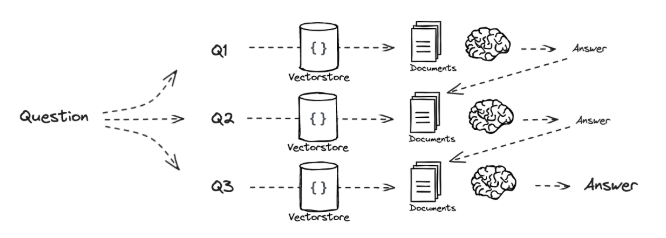

In [14]:
# Prompt
template = """这是你需要回答的问题:

\n --- \n {question} \n --- \n

这是所有可用的背景问题+答案对:

\n --- \n {q_a_pairs} \n --- \n

这是与该问题相关的额外上下文: 

\n --- \n {context} \n --- \n

利用上述上下文以及所有背景问题+答案对来回答问题: \n {question}
"""

decomposition_prompt = PromptTemplate.from_template(template)

In [15]:
def format_qa_pair(question,answer):
    formatted_string = ""
    formatted_string += f"Question: {question}\nAnswer: {answer}\n\n"
    return formatted_string.strip()

q_a_pairs = ""
for q in questions:
    
    rag_chain = (
        {"context": itemgetter("question") | retriever,
         "question": itemgetter("question"),
         "q_a_pairs": itemgetter("q_a_pairs")}
         | decomposition_prompt
         | llm
         | StrOutputParser())
    
    answer = rag_chain.invoke({"question": q, "q_a_pairs": q_a_pairs})
    q_a_pair = format_qa_pair(q,answer)
    q_a_pairs = q_a_pairs + "\n---\n"+ q_a_pair

In [ ]:
print(answer)

将大语言模型（LLM）集成到自主智能体系统中以实现自主决策，需要结合系统的核心模块，并通过合理的架构设计和交互机制，使LLM能够有效地参与决策过程。以下是具体的集成方法和步骤：

---

### 1. **明确LLM在系统中的角色**
根据问题1的答案，LLM作为系统的“大脑”或控制核心，负责**决策、规划和执行任务**。因此，在集成时应将其定位为**决策引擎**，负责从环境信息中提取关键数据，生成行动策略，并协调其他模块的协作。

---

### 2. **与感知模块对接**
- **输入接口**：LLM需要接收来自感知模块的实时环境信息，如传感器数据、用户输入、历史记录等。
- **信息处理**：LLM对这些信息进行语义理解，提取关键特征，为后续决策提供依据。
- **示例**：如果智能体是机器人，感知模块可能提供图像、声音、温度等数据，LLM则基于这些数据判断当前状态并生成下一步动作。

---

### 3. **与记忆与学习模块整合**
- **知识存储与更新**：LLM可以与记忆模块配合，存储过往经验、行为模式和任务结果，从而支持持续学习。
- **动态调整**：通过记忆模块反馈的历史数据，LLM可以优化其决策逻辑，提高适应性和效率。
- **示例**：在长期任务中，LLM可以根据之前的成功/失败案例，调整策略以提升成功率。

---

### 4. **与规划与决策模块协同工作**
- **目标驱动的决策**：LLM根据系统设定的目标（如完成某项任务、优化资源使用等），生成一系列行动计划。
- **动态调整**：当环境发生变化或计划受阻时，LLM能够重新评估并调整策略。
- **示例**：在自动驾驶场景中，LLM可以实时分析路况、交通规则和乘客需求，生成最优行驶路径。

---

### 5. **与执行模块联动**
- **指令生成**：LLM将决策转化为具体的操作指令，例如生成代码、文本、控制信号等。
- **多模态输出**：LLM可以生成多种类型的输出，适应不同类型的执行模块（如控制硬件、生成文本、执行脚本等）。
- **示例**：在客服系统中，LLM生成自然语言回复，由执行模块发送给用户。

---

### 6. **与反馈与评估模块结合**
- **结果评估**：LLM接收来自反馈模块的执行结果，评估是否达成目标。
- **自适应优化*

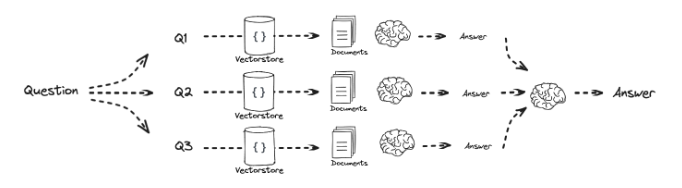

In [19]:
from langchain_classic import hub
prompt_rag = hub.pull("rlm/rag-prompt")

def retrieve_and_rag(question, prompt_rag, sub_question_generator_chain):
   sub_questions = sub_question_generator_chain.invoke({"question": question})
   rag_results = []
   for sub_question in sub_questions:
      # Retrieve documents for each sub-question
      retrived_docs = retriever.invoke(sub_question)
      # use retrieved documents and sub-question in chain
      answer = (prompt_rag | llm | StrOutputParser()).invoke({"context": retrived_docs, "question": sub_question})
      rag_results.append(answer)
   return rag_results,sub_questions

answers,questions = retrieve_and_rag(question, prompt_rag, generate_queries_decomposition)

def format_qa_pairs(questions, answers):
   formatted_string = ""
   for i ,(question,answer) in enumerate(zip(questions,answers),start = 1):
      formatted_string += f"Question {i}: {question}\nAnswer: {answer}\n\n"
   return formatted_string.strip()

context = format_qa_pairs(questions, answers)

template = """
这里是一组问答对：
{context}
利用这些内容综合回答问题：{question}
"""

prompt = PromptTemplate.from_template(template)

final_rag_chain = (
     prompt 
     | llm
     | StrOutputParser()
)
response = final_rag_chain.invoke({"context": context, "question": question})
print(response)  


基于大语言模型（LLM）的自主智能体系统的主要组成部分可以归纳为以下几个核心部分：

1. **大语言模型（LLM）作为“大脑”**  
   LLM 是整个系统的核心，负责处理信息、理解环境、进行推理和决策。它不仅能够生成文本，还能作为通用问题解决器，在各种任务中发挥作用，如规划、推理和执行。

2. **目标设定模块**  
   系统需要明确的目标或任务，这些目标可以是用户定义的，也可以是通过学习自动形成的。目标设定决定了智能体的行为方向和优先级。

3. **感知与交互模块**  
   该模块负责从外部环境中获取信息，例如通过 API 接口、传感器、用户输入等方式。这些信息用于更新系统的状态，并影响其决策过程。

4. **决策与规划模块**  
   基于当前状态和目标，决策模块制定行动计划。这一过程可能涉及逻辑推理、策略选择以及对不同选项的评估，以实现最优或最合适的行动方案。

5. **学习与适应模块**  
   智能体需要具备学习能力，能够根据经验调整策略，优化行为表现。这可以通过强化学习、反馈机制或在线学习等方式实现。

6. **执行与反馈模块**  
   执行模块负责将决策转化为具体操作，例如调用工具、发送指令或执行任务。同时，系统会通过反馈机制评估执行结果，为后续决策提供依据。

7. **记忆与知识库（可选）**  
   一些高级系统可能包含记忆模块，用于存储历史数据、经验教训或知识，以支持更复杂的推理和决策。

综上所述，一个基于 LLM 的自主智能体系统是一个由多个模块协同工作的复杂架构，其中 LLM 起到“大脑”的作用，而其他模块则共同支撑其感知、决策、执行和学习能力，使其能够在动态环境中自主运作。
